# Imports & paths

In [1]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

os.chdir("..")

from experiment_utils.utils import *

In [2]:
sns.set_palette('colorblind')

In [3]:
response_data = "data/processed/responses_processed.csv"
edit_events_data_path = "data/processed/edit_events.csv"
pc_data_path = "data/processed/pc_data.csv" 

# Prepare data

In [4]:
responses = pd.read_csv(response_data)
responses

,StartDate,EndDate,Status,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,DistributionChannel,UserLanguage,...,made_edits,response_time_minutes,response_quality,AnonymizedID,Anonymized_PID,LLM_impact_abbrev,att1_passed,att2_passed,passed_both_att_checks,num_edited_sentences
0,2026-05-21 14:38:41,2026-05-21 15:07:13,IP Address,100,1711,True,2026-05-21 15:07:14,R_4tvghDvC4oZm2e5,anonymous,EN,...,True,28.516667,high_quality,G1_C1,G1_C1,Very beneficial,1,1,1,9
1,2026-05-21 14:02:01,2026-05-21 14:35:16,IP Address,100,1994,True,2026-05-21 14:35:17,R_2MAJ7CWkGG77fjM,anonymous,EN,...,True,33.233333,high_quality,G1_C2,G1_C2,More negative than positive,1,1,1,9
2,2026-05-21 14:02:00,2026-05-21 14:26:42,IP Address,100,1482,True,2026-05-21 14:26:43,R_8JJzTTgaMsugyuk,anonymous,EN,...,True,24.700000,high_quality,G1_C3,G1_C3,Very detrimental,1,1,1,9
3,2026-05-21 14:02:01,2026-05-21 14:20:18,IP Address,100,1097,True,2026-05-21 14:20:19,R_8rv978TZzUt3U54,anonymous,EN,...,True,18.283333,high_quality,G1_C4,G1_C4,More negative than positive,1,1,1,10
4,2026-05-21 14:02:21,2026-05-21 14:25:20,IP Address,100,1378,True,2026-05-21 14:25:21,R_2szGwhAqpRYx3Wm,anonymous,EN,...,True,22.966667,high_quality,G1_C5,G1_C5,More positive than negative,1,1,1,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,2026-05-22 18:21:04,2026-05-22 18:34:39,IP Address,100,815,True,2026-05-22 18:34:40,R_4BlGFW4T0CllOiz,anonymous,EN,...,True,13.583333,high_quality,G5_C17,G5_C17,Very beneficial,1,0,0,4
101,2026-05-22 18:21:05,2026-05-22 18:58:07,IP Address,100,2222,True,2026-05-22 18:58:08,R_2IwbQBIy7ODKHCN,anonymous,EN,...,True,37.033333,high_quality,G5_C18,G5_C18,No opinion,1,1,1,13
102,2026-05-22 18:23:32,2026-05-22 18:36:41,IP Address,100,789,True,2026-05-22 18:36:41,R_80qJgoXZb6sJfW3,anonymous,EN,...,True,13.150000,high_quality,G5_C19,G5_C19,More positive than negative,1,1,1,8
103,2026-05-22 18:30:29,2026-05-22 18:52:27,IP Address,100,1318,True,2026-05-22 18:52:28,R_1CHI3VTmvm7BA9S,anonymous,EN,...,True,21.966667,high_quality,G5_C20,G5_C20,More negative than positive,1,0,0,9


In [5]:
# print number of responses per generation
print(responses['g'].value_counts().sort_index())

g
1    21
2    21
3    21
4    21
5    21
Name: count, dtype: int64


## Collect edit events

In [6]:
# collect edit events
rows = []

# sort data by generation and chain
responses = responses.sort_values(by=['g', 'c'])

for row_idx, row in responses.iterrows():
    edits = decode_qualtrics_data(row['EditPairsJSON'])
    explanations = decode_qualtrics_data(row['EditExplanationsJSON'])

    for edit_idx, exp in enumerate(explanations, start=1):
        sent_idx = exp.get('index')

        rows.append({
            'chain': row['c'],
            'generation': row['g'],
            'edit_idx': edit_idx,
            'sentence_idx': sent_idx,
            'original': edits[sent_idx].get('orig', ''),
            'edited': edits[sent_idx].get('edited', ''),
            'explanation': exp.get('explanation', 'NA'),
            'participant': row['ResponseId']
        })

edit_events_df = pd.DataFrame(
    rows,
    columns=['generation', 'chain', 'participant', 'edit_idx', 'sentence_idx', 'original', 'edited', 'explanation']
)

edit_events_df = edit_events_df.sort_values(by=['generation', 'chain', 'edit_idx'])

display(edit_events_df.head())


edit_events_df.to_csv(edit_events_data_path, index=False)
print(f"Saved edit events data to {edit_events_data_path}")

,generation,chain,participant,edit_idx,sentence_idx,original,edited,explanation
0,1,1,R_4tvghDvC4oZm2e5,1,0,A growing number of companies are migrating to...,A growing number of companies are migrating to...,Ai models don't over explain or use the pronou...
1,1,1,R_4tvghDvC4oZm2e5,2,1,"According to a recent industry survey, 81% of ...","According to a recent industry survey, 81% of ...","Ai models compress the text unless asked, whil..."
2,1,1,R_4tvghDvC4oZm2e5,3,2,"While cost savings, scalability, and flexibili...","While cost savings, scalability, and flexibili...","commonly cited felt too formal, which is usual..."
3,1,1,R_4tvghDvC4oZm2e5,4,3,Executives report feeling compelled to moderni...,Executive side is compelled to modernize IT sy...,Executives report feeling seemed to hard to un...
4,1,1,R_4tvghDvC4oZm2e5,5,5,Rather than waiting for clear returns on inves...,Rather than waiting for clear returns on inves...,I added now there to take the listener in and ...


Saved edit events data to data/processed/edit_events.csv


# Inspect explanations

In [7]:
edit_events_processed = edit_events_df.copy()

edit_events_processed.shape

(846, 8)

## Find uninformative explanations

### Word count

In [8]:
edit_events_processed['explanation_word_count'] = edit_events_processed['explanation'].apply(lambda x: len(str(x).split()))

edit_events_processed['explanation_word_count'].describe()

count    846.000000
mean      12.455083
std       11.699886
min        2.000000
25%        5.000000
50%        9.000000
75%       16.000000
max      126.000000
Name: explanation_word_count, dtype: float64

In [9]:
# find explanations that contain less then 4 words
short_explanations = edit_events_processed[edit_events_processed['explanation_word_count'] < 4]
print(f"Short explanations (less than 4 words): {len(short_explanations)} ({len(short_explanations)/len(edit_events_processed)*100:.2f}%)")

Short explanations (less than 4 words): 119 (14.07%)


### Cross-references

In [10]:
# function to check if an explanation contains cross-referencing language

def is_cross_ref(explanation, verbose=False):
    # automatically accept explanations with more than 3 words 
    if len(explanation.strip().split()) > 3:
        return False
    
    cross_ref_patterns = [
    r'\babove\b', 
    r'\bbelow\b', 
    r'\bprevious\b', 
    r'\bnext\b', 
    r'\bsame\b',
    r'\bsee\b',
    ] 
    
    # compile the regex patterns into a single pattern
    cross_ref_regex = re.compile('|'.join(cross_ref_patterns), re.IGNORECASE)

    cross_ref = cross_ref_regex.search(explanation)
    if verbose:
        if cross_ref is not None:
            print(f"Explanation:           {explanation}")
            print(f"Cross-ref expression:  {cross_ref.group()} (span: {cross_ref.start()}-{cross_ref.end()})\n")
    return bool(cross_ref)

edit_events_processed['is_cross_ref'] = edit_events_processed['explanation'].apply(is_cross_ref, verbose=True)

Explanation:           See above comment.
Cross-ref expression:  See (span: 0-3)

Explanation:           added to above
Cross-ref expression:  above (span: 9-14)

Explanation:           used above
Cross-ref expression:  above (span: 5-10)

Explanation:           used above
Cross-ref expression:  above (span: 5-10)

Explanation:           used above
Cross-ref expression:  above (span: 5-10)

Explanation:           used above
Cross-ref expression:  above (span: 5-10)

Explanation:           used above
Cross-ref expression:  above (span: 5-10)

Explanation:           used above
Cross-ref expression:  above (span: 5-10)

Explanation:           used above
Cross-ref expression:  above (span: 5-10)

Explanation:           Consolidated above
Cross-ref expression:  above (span: 13-18)

Explanation:           Consolidated above
Cross-ref expression:  above (span: 13-18)

Explanation:           Consolidated above
Cross-ref expression:  above (span: 13-18)

Explanation:           See above.
Cross-

In [11]:
cross_ref_events = edit_events_processed[edit_events_processed['is_cross_ref'] == True]
print(f"Cross-ref explanations: {len(cross_ref_events)} ({len(cross_ref_events)/len(edit_events_processed)*100:.2f}%)")

cross_ref_events

Cross-ref explanations: 25 (2.96%)


,generation,chain,participant,edit_idx,sentence_idx,original,edited,explanation,explanation_word_count,is_cross_ref
67,1,8,R_2b2fxpeCJUXhgin,4,3,Officials said the transfer would strengthen b...,,See above comment.,3,True
273,2,12,R_1rA73TfMvCWnmDD,3,3,Barbara served as the first lady from 1989 to ...,,added to above,3,True
284,2,14,R_8lFeDXjmj8Ub029,3,2,It also has peaks ranging from 100 meters to n...,,used above,2,True
286,2,14,R_8lFeDXjmj8Ub029,5,4,Most are concealed beneath up to two kilometer...,,used above,2,True
287,2,14,R_8lFeDXjmj8Ub029,6,5,This makes direct observation impossible witho...,,used above,2,True
289,2,14,R_8lFeDXjmj8Ub029,8,7,Scientists warn that geothermal heat from volc...,,used above,2,True
291,2,14,R_8lFeDXjmj8Ub029,10,9,The discovery also offers new insight into Ant...,,used above,2,True
293,2,14,R_8lFeDXjmj8Ub029,12,11,Researchers plan further surveys to map the ar...,,used above,2,True
294,2,14,R_8lFeDXjmj8Ub029,13,12,It also assess how subglacial volcanic systems...,,used above,2,True
413,3,10,R_8k55aPeLlFMKLQd,4,4,It is also required to perform forcible entry ...,,Consolidated above,2,True


In [12]:
# locate cross-ref explanations in the data

# participants with cross-reference explanations
participants_with_cross_refs = cross_ref_events['participant'].unique()

print(f"Participants with cross-ref explanations: {len(participants_with_cross_refs)} out of {len(edit_events_df['participant'].unique())} ({len(participants_with_cross_refs)/len(edit_events_df['participant'].unique())*100:.2f}%)")

# display participants with cross-ref explanations and their chain and generation information
cross_ref_participant_info = cross_ref_events[['participant', 'chain', 'generation', 'explanation']].drop_duplicates()
display(cross_ref_participant_info)

Participants with cross-ref explanations: 8 out of 102 (7.84%)


,participant,chain,generation,explanation
67,R_2b2fxpeCJUXhgin,8,1,See above comment.
273,R_1rA73TfMvCWnmDD,12,2,added to above
284,R_8lFeDXjmj8Ub029,14,2,used above
413,R_8k55aPeLlFMKLQd,10,3,Consolidated above
461,R_8USKFIb3MjZzdPH,16,3,See above.
552,R_229lKte16OIh0hC,5,4,See above.
600,R_6VkBsXCJJ6fgQlX,12,4,See above.
807,R_2IwbQBIy7ODKHCN,18,5,As above.
817,R_2IwbQBIy7ODKHCN,18,5,See reply above.


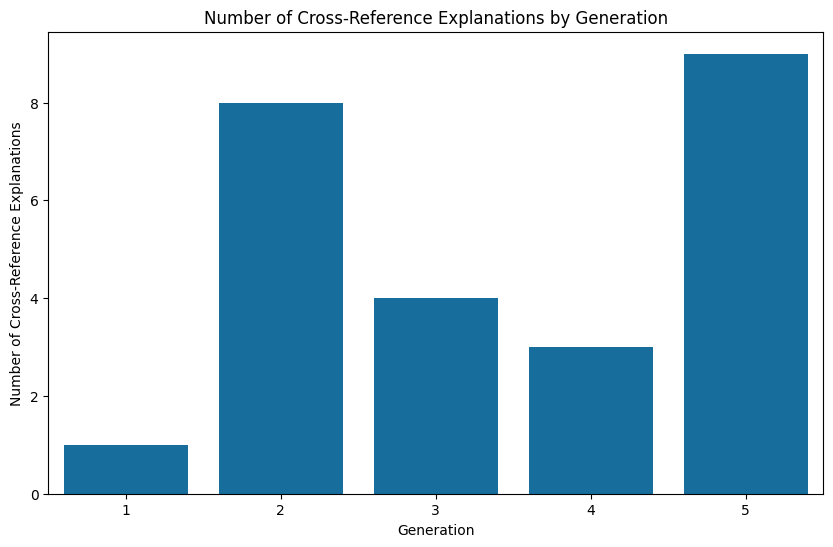

In [13]:
# plot number of cross-ref explanations by generation
cross_ref_counts = cross_ref_events.groupby('generation').size().reset_index(name='cross_ref_count')
plt.figure(figsize=(10, 6))
sns.barplot(data=cross_ref_counts, x='generation', y='cross_ref_count')
plt.title('Number of Cross-Reference Explanations by Generation')
plt.xlabel('Generation')
plt.ylabel('Number of Cross-Reference Explanations')
plt.show()

### Short explanations without cross-referencing

In [14]:
# if short and does not contain cross-ref language, print
short_non_cross_ref_explanations = edit_events_processed[
    (edit_events_processed['explanation_word_count'] < 4) &
    (edit_events_processed['is_cross_ref'] == False)
]

short_non_cross_ref_explanations

,generation,chain,participant,edit_idx,sentence_idx,original,edited,explanation,explanation_word_count,is_cross_ref
26,1,3,R_8JJzTTgaMsugyuk,9,8,Whether blockchain can truly replace Wikipedia...,The future of Wikipedia would seem to be uncer...,"more descriptive, relatable",3,False
32,1,4,R_8rv978TZzUt3U54,6,5,“We are committed to rebuilding trust with our...,"He also said that they are ""committed to rebui...",adding human element,3,False
33,1,4,R_8rv978TZzUt3U54,7,6,“This moment demands transparency and decisive...,He added that “This moment demands transparenc...,adding human element,3,False
34,1,4,R_8rv978TZzUt3U54,8,7,The investigation also prompted renewed scruti...,As a result of the investigation there has bee...,adding human element,3,False
35,1,4,R_8rv978TZzUt3U54,9,8,Industry analysts say the shake-up could tempo...,Industry analysts say the shake-up could tempo...,adding human element,3,False
...,...,...,...,...,...,...,...,...,...,...
821,5,19,R_80qJgoXZb6sJfW3,3,3,Accepting the award on behalf of the group was...,Accepting the award on behalf of the group was...,prefer the flow,3,False
822,5,19,R_80qJgoXZb6sJfW3,4,4,She then urged further talk of disarmament and...,She then urged further talk of disarmament and...,sounds better,2,False
824,5,19,R_80qJgoXZb6sJfW3,6,6,Analysts said the prize could intensify diplom...,Analysts said the prize could intensify diplom...,Is less AI,3,False
825,5,19,R_80qJgoXZb6sJfW3,7,7,"Founded in 2007, the coalition includes 600 pa...","Founded in 2007, the coalition includes 600 pa...",more precise,2,False


### Explanations repeated verbatim (excluding cross-referencing ones)

In [15]:
non_cross_ref_explanations = edit_events_processed[edit_events_processed['is_cross_ref'] == False]
print(f"Non-cross-ref explanations: {len(non_cross_ref_explanations)} ({len(non_cross_ref_explanations)/len(edit_events_processed)*100:.2f}%)")

Non-cross-ref explanations: 821 (97.04%)


In [16]:
# for each participants, find if any explanations are identical, and for those that are, print the participant, chain, generation, explanation, and the number of times that explanation appears for that participant
duplicate_explanations = non_cross_ref_explanations.groupby(['generation', 'chain', 'participant', 'explanation']).size().reset_index(name='count')
duplicate_explanations = duplicate_explanations[duplicate_explanations['count'] > 1]
duplicate_explanations = duplicate_explanations.sort_values(['generation', 'chain'])
duplicate_explanations

,generation,chain,participant,explanation,count
31,1,4,R_8rv978TZzUt3U54,adding human element,5
40,1,5,R_2szGwhAqpRYx3Wm,It sounds better.,2
70,1,9,R_6HoY1nfmTzov7xF,Less wording and less AI. Used more of my own ...,11
88,1,13,R_5SLDIhUj45BEHZL,The LLM seems to follow a certain sentence str...,4
89,1,13,R_5SLDIhUj45BEHZL,The LLM seems to follow a certain sentence str...,2
137,1,21,R_3oiLMgHlQvZaYVI,to consolidate the thought,2
143,2,1,R_2qldCHU2ofrZ6EF,I changed to wording to sound more human like,2
154,2,2,R_22Mjh6yrlA3QR7f,replaced words with similes to make it sound m...,3
229,2,10,R_625CKqg4uVNwJdH,removed unnecessary word,2
230,2,10,R_625CKqg4uVNwJdH,shorten the sentence,2


## Clean explanations and inspect resulting data 

Drop cross-reference explanations and duplicates within each participant (keeping only first occurrence)

In [17]:
# drop cross-reference explanations
pc_data = edit_events_processed[edit_events_processed['is_cross_ref'] == False]

# sort by generation, chain, and edit index to ensure we keep the first occurrence of each explanation within each generation
pc_data = pc_data.sort_values(by=['generation', 'chain', 'edit_idx'])
# drop duplicates within each participant
pc_data = pc_data.drop_duplicates(subset=['participant', 'explanation'], keep='first')
pc_data.shape

print(pc_data.shape)

# num observations per generation after cleaning
obs_per_gen = pc_data['generation'].value_counts().sort_index()
print(f"\nObservations per generation after cleaning:\n{obs_per_gen}")

obs_per_chain = pc_data['chain'].value_counts().sort_index()
print(f"\nObservations per chain after cleaning:")
display(obs_per_chain.describe())

(732, 10)

Observations per generation after cleaning:
generation
1    138
2    167
3    150
4    148
5    129
Name: count, dtype: int64

Observations per chain after cleaning:


count    21.000000
mean     34.857143
std       6.732650
min      16.000000
25%      32.000000
50%      35.000000
75%      39.000000
max      50.000000
Name: count, dtype: float64

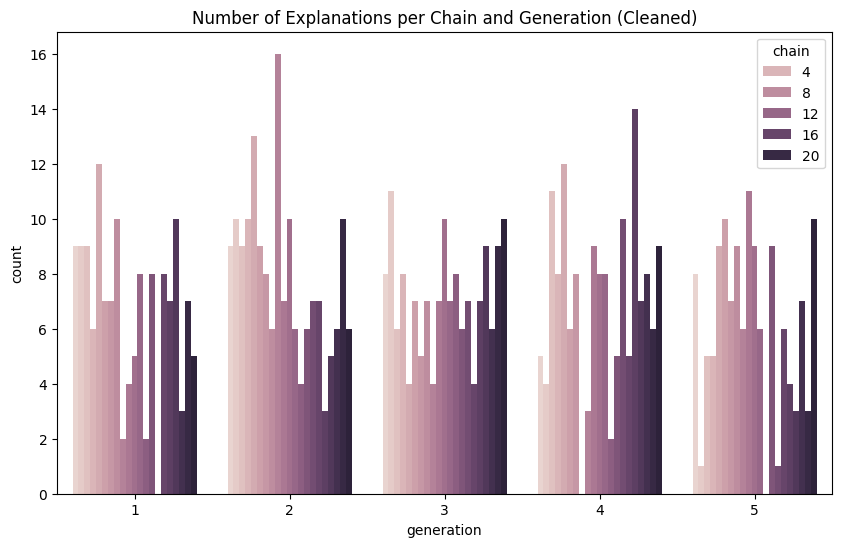

In [18]:
# boxplot number of explanations per chain and generation after cleaning
# y-axis: number of explanations

plt.figure(figsize=(10, 6))
sns.countplot(data=pc_data, x='generation', hue='chain') 
plt.title('Number of Explanations per Chain and Generation (Cleaned)')
plt.show()

# Embedding explanations and PCA

In [19]:
pc_data.isna().sum()

generation                0
chain                     0
participant               0
edit_idx                  0
sentence_idx              0
original                  0
edited                    0
explanation               0
explanation_word_count    0
is_cross_ref              0
dtype: int64

In [20]:
explanation_texts = pc_data["explanation"].fillna("").tolist() 

embedding_model = SentenceTransformer("all-mpnet-base-v2")

embeddings = embedding_model.encode(explanation_texts) 

print(embeddings.shape)
# (n_observations, 768)

pc_data["explanation_embedding"] = list(embeddings)

(732, 768)


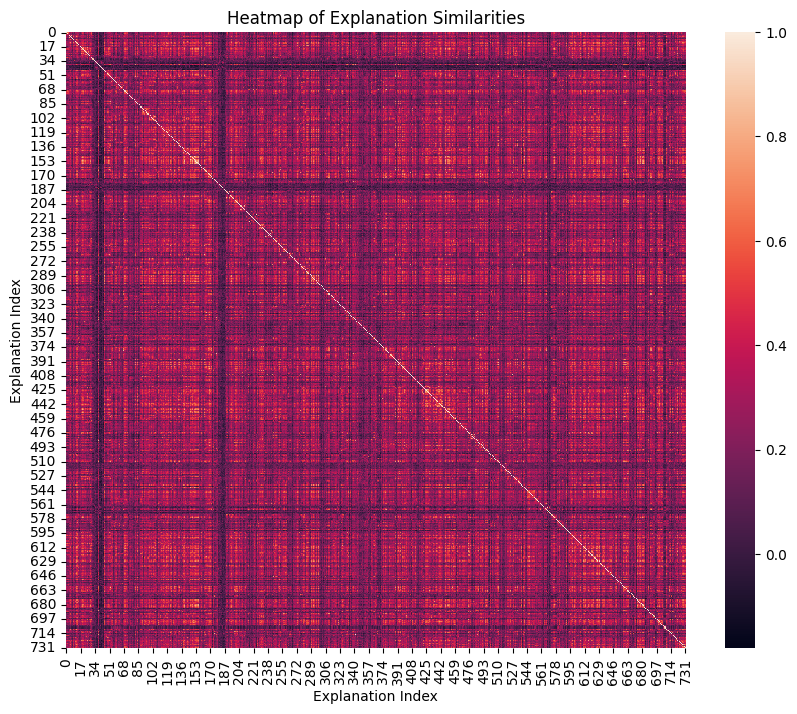

In [21]:
similarities = embedding_model.similarity(embeddings, embeddings)

# heatmap of similarities
plt.figure(figsize=(10, 8))
sns.heatmap(similarities)
plt.title('Heatmap of Explanation Similarities')
plt.xlabel('Explanation Index')
plt.ylabel('Explanation Index')
plt.show()

Light rectangles across on the diagonal correspond to repeated explanations. 

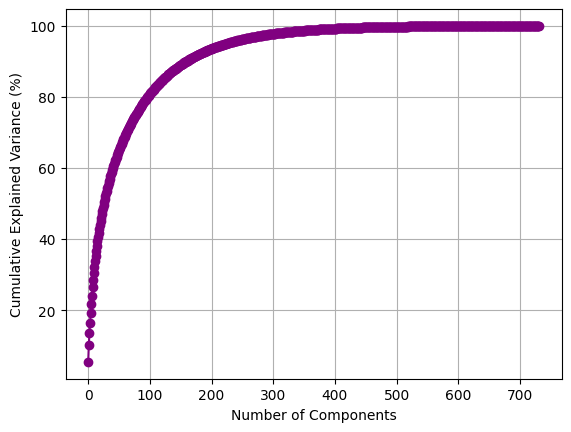

In [22]:
pca = PCA()
pca.fit(embeddings)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(cumulative_variance * 100, marker='o', color='purple')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
# plt.title('PCA Explained Variance')
plt.grid()
plt.show()

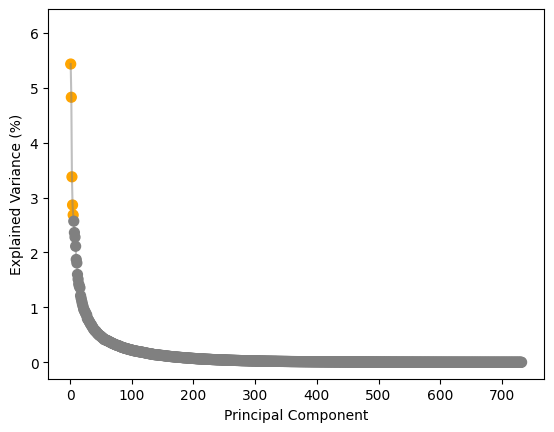

In [23]:
# scree plot of explained variance
plt.figure()
x = np.arange(1, len(explained_variance) + 1)
y = explained_variance * 100
# first five points purple
colors = ['orange' if i < 5 else 'gray' for i in range(len(y))]
# connect points with a faint line for readability
plt.plot(x, y, color='gray', alpha=0.5)
plt.scatter(x, y, c=colors, s=50)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.ylim(min(y) - 0.3, max(y) + 1)
# plt.title('Scree Plot')
# plt.grid(True)
plt.show()

In [24]:
k = 5
pca_k = PCA(n_components=k)
pcs = pca_k.fit_transform(embeddings)

# print variation explained by each of the first k principal components
print(f"Explained variance by the first {k} principal components:")
for i in range(k):
    print(f"PC{i+1}: {explained_variance[i]*100:.1f}% ({cumulative_variance[i]*100:.1f}% cumulative)")

print("Reduced shape:", pcs.shape)

for i in range(pcs.shape[1]):
    pc_data[f"pc{i+1}"] = pcs[:, i]

# save to csv
pc_data.to_csv(pc_data_path, index=False)

Explained variance by the first 5 principal components:
PC1: 5.4% (5.4% cumulative)
PC2: 4.8% (10.3% cumulative)
PC3: 3.4% (13.6% cumulative)
PC4: 2.9% (16.5% cumulative)
PC5: 2.7% (19.2% cumulative)
Reduced shape: (732, 5)


<Axes: xlabel='pc1', ylabel='pc2'>

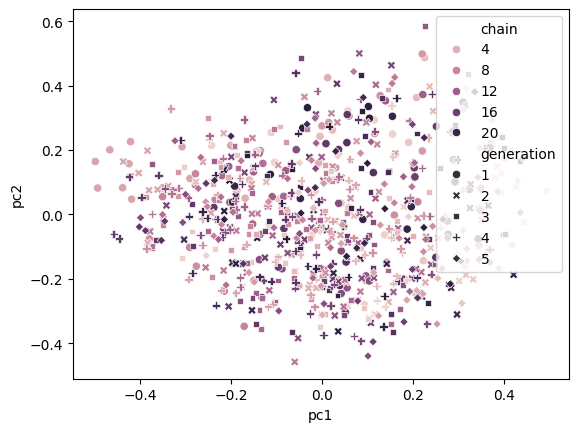

In [25]:
sns.scatterplot(pc_data, x="pc1", y="pc2", hue="chain", style="generation")

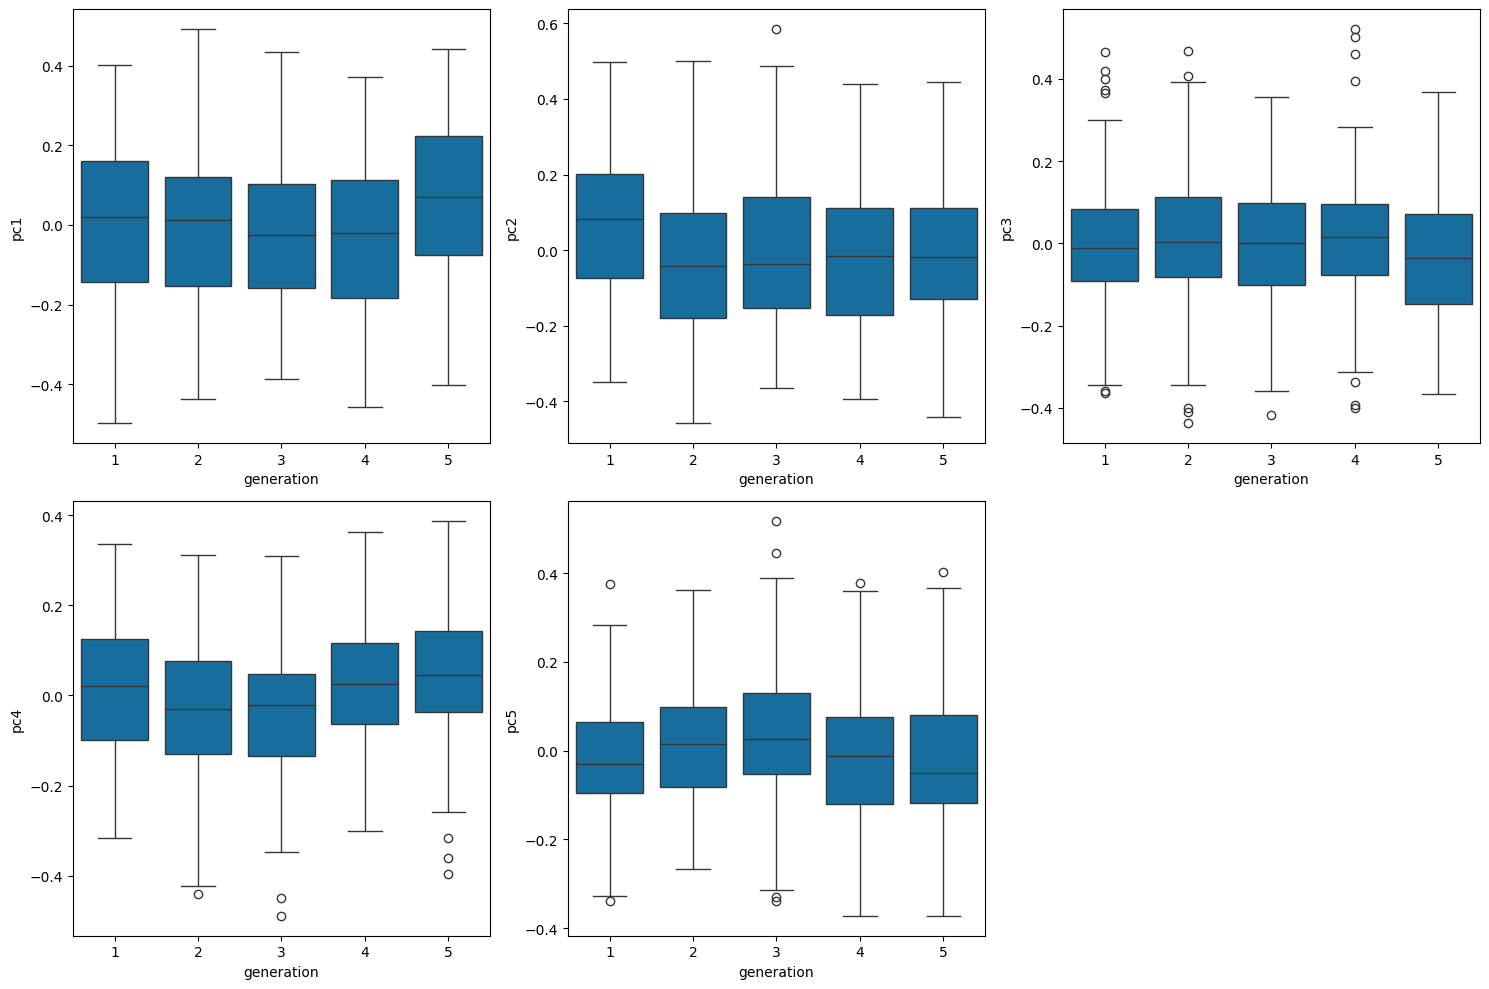

In [26]:
# one axis for each pc, plot the distribution of values for each generation
plt.figure(figsize=(15, 10))
for i in range(k):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=pc_data, x='generation', y=f'pc{i+1}')
plt.tight_layout()
plt.show()

/var/folders/cc/4nxmfkrs02lfj_4p5s10tmzw0000gn/T/ipykernel_4169/1089640215.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=chain_means, x='generation', y='mean_pc', ci='sd',color='red', marker='o', linewidth=2, ax=ax)
/var/folders/cc/4nxmfkrs02lfj_4p5s10tmzw0000gn/T/ipykernel_4169/1089640215.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=chain_means, x='generation', y='mean_pc', ci='sd',color='red', marker='o', linewidth=2, ax=ax)
/var/folders/cc/4nxmfkrs02lfj_4p5s10tmzw0000gn/T/ipykernel_4169/1089640215.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=chain_means, x='generation', y='mean_pc', ci='sd',color='red', marker='o', linewidth=2, ax=ax)
/var/folders/cc/4nxmfkrs02lfj_4p5s10tmzw0000gn/T/ipykernel_4169/1089640215.py:16: FutureWarning: 

The `ci` parameter is deprecate

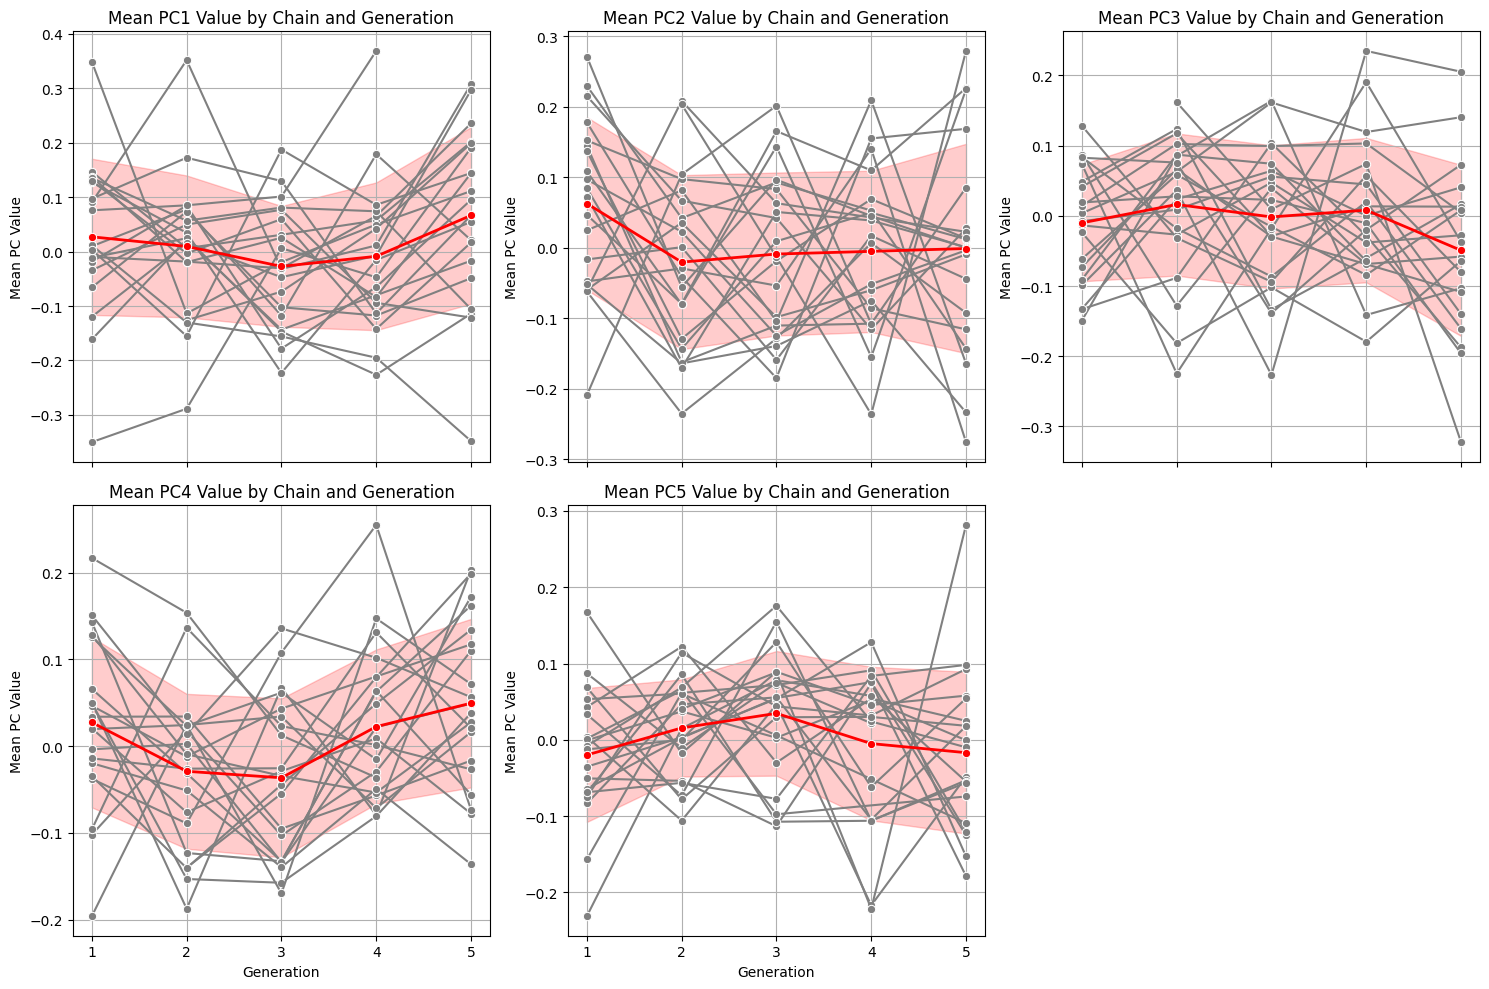

In [27]:
# for each PC, plot mean value per chain per generation, with lines connecting generations for each chain

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
axes = axes.flatten()

for i in range(k):
    chain_means = (
        pc_data
        .groupby(['chain', 'generation'], as_index=False)[f'pc{i+1}']
        .mean()
        .rename(columns={f'pc{i+1}': 'mean_pc'})
    )
    ax = axes[i]
    
    sns.lineplot(data=chain_means, x='generation', y='mean_pc', hue='chain', palette={chain: 'gray' for chain in chain_means['chain'].unique()}, legend=False, marker='o', ax=ax)
    sns.lineplot(data=chain_means, x='generation', y='mean_pc', ci='sd',color='red', marker='o', linewidth=2, ax=ax)
    
    ax.set_title(f'Mean PC{i+1} Value by Chain and Generation')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Mean PC Value')
    ax.set_xticks(range(1, 6))
    ax.grid()

for j in range(k, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Interpret PCs

In [28]:
pc_data.columns

Index(['generation', 'chain', 'participant', 'edit_idx', 'sentence_idx',
       'original', 'edited', 'explanation', 'explanation_word_count',
       'is_cross_ref', 'explanation_embedding', 'pc1', 'pc2', 'pc3', 'pc4',
       'pc5'],
      dtype='object')

In [29]:
# explanations with extreme values on each PC
for pc in [f"pc{i}" for i in range(1, pcs.shape[1]+1)]:
    print(f"\nExplanations with extreme values on {pc}:")
    largest = pc_data.nlargest(5,pc)[["explanation", pc, "chain", "generation"]]
    smallest = pc_data.nsmallest(5,pc)[["explanation", pc, "chain", "generation"]]
    print("Largest:")
    print(f"{largest['explanation'].tolist()}")
    print("Largest generation and chain info:")
    print(f"{largest[['generation', 'chain']].values.tolist()}")
    print("Smallest:")
    print(f"{smallest['explanation'].tolist()}")
    print("Smallest generation and chain info:")
    print(f"{smallest[['generation', 'chain']].values.tolist()}")


Explanations with extreme values on pc1:
Largest:
['replaced words to make it sound more human', 'changed words and added some to make it sound more human', 'simplified/changed words to seem more human written', 'changed what I could to seem human written', 'Just changing the order of words makes it seem more human-like']
Largest generation and chain info:
[[2, 2], [2, 2], [5, 11], [5, 11], [3, 21]]
Smallest:
['The domestic party scenes are the majority.', "They don't fuel anyrhing.", 'Everyone who watches, so not nearly.', 'Data required to support the claim', 'Needed data to support the claim']
Smallest generation and chain info:
[[1, 5], [1, 5], [1, 5], [4, 17], [4, 17]]

Explanations with extreme values on pc2:
Largest:
['it sounds more natural and humanlike', 'It seems more human', 'It sounded more human.', 'to make it sound less robotic, more personal', 'Such as sounds like AI']
Largest generation and chain info:
[[3, 13], [2, 13], [1, 6], [1, 3], [3, 15]]
Smallest:
['Wrong punc

In [30]:
originals = list(pc_data[(pc_data['generation'] == 1) & (pc_data['chain'] == 5)]['original'])
edited = list(pc_data[(pc_data['generation'] == 1) & (pc_data['chain'] == 5)]['edited'])
explanations = list(pc_data[(pc_data['generation'] == 1) & (pc_data['chain'] == 5)]['explanation'])

for o, e, exp in zip(originals, edited, explanations):
    print(f"Original: {o}")
    print(f"Edited:   {e}")
    print(f"Explanation: {exp}\n")

Original: Americans erupt every February for the Super Bowl, transforming a football game into an unofficial national holiday.
Edited:   Americans gather together every February for the Super Bowl; transforming a football game into an unofficial national holiday.
Explanation: Erupt is a strange choice.

Original: The championship matchup of the National Football League routinely draws more than 100 million viewers, making it the most-watched television event in the United States.
Edited:   The championship matchup of the National Football League routinely draws more than 100 million viewers, making it the most-watched television event in the United States, and almost a billion viewers worldwide.
Explanation: Including the global audience hikes the number.

Original: But the frenzy extends far beyond the final score.
Edited:   But the excitement extends far beyond the final scoreline.
Explanation: Frenzy is inappropriate.

Original: For fans, the Super Bowl represents the climax of a mo

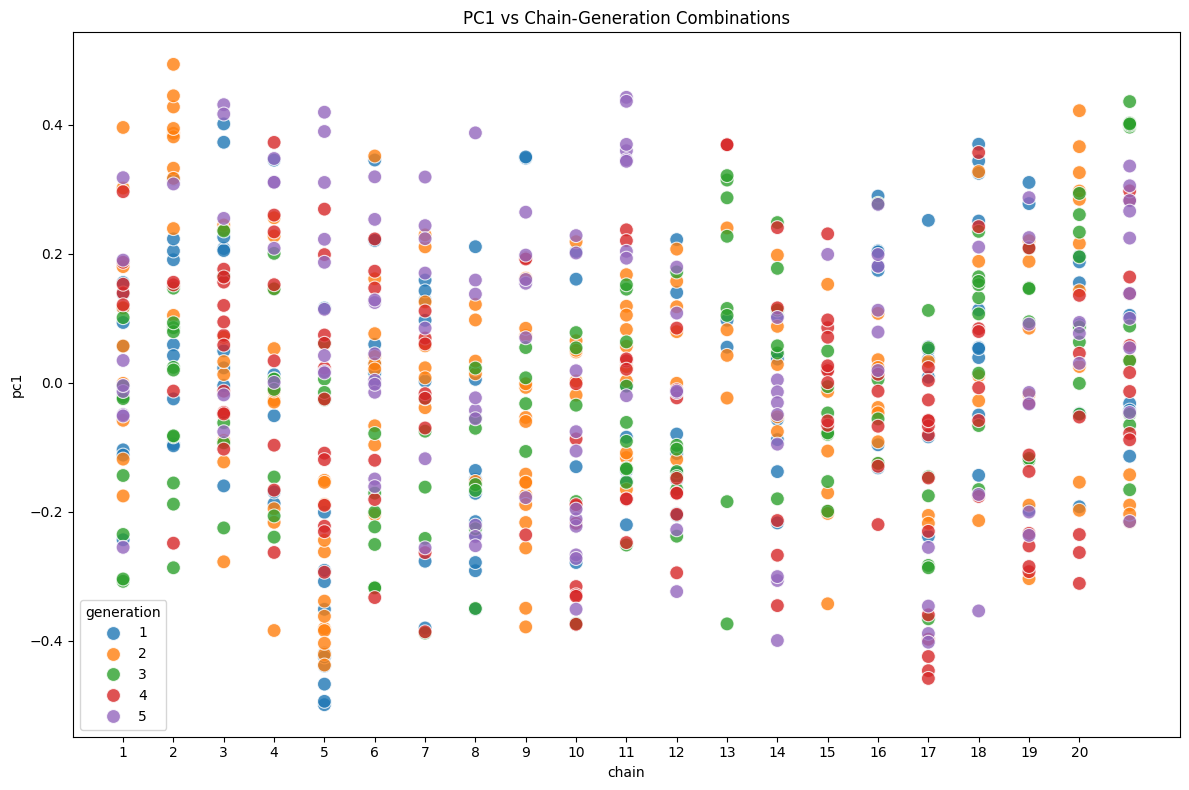

In [31]:
# see to what extent PC1 is correlated with participant

plt.figure(figsize=(12, 8))
sns.scatterplot(data=pc_data, x='chain', y='pc1', hue='generation', palette='tab10', s=100, alpha=0.8)
plt.title('PC1 vs Chain-Generation Combinations')
plt.xticks(range(1, 21))
plt.tight_layout() 